# OS-Optimized Speech Emotion Recognition with Wav2Vec2 on RAVDESS

This notebook is written for **Windows + Jupyter + NVIDIA GPU**.

Project scope:

- Download RAVDESS through `kagglehub`.
- Parse RAVDESS filenames into emotion labels.
- Use CPU multiprocessing for audio loading, mono conversion, resampling, normalization, and cache creation.
- Use Wav2Vec2 to extract speech embeddings.
- Train a lightweight classifier for 8 emotions.
- Evaluate using actor-independent splits.
- Produce Operating Systems evidence: process management, scheduling, synchronization, file management, memory management, caching, and benchmarks.

> This project is a general Speech Emotion Recognition project. It is not a clinical, dental, or anxiety-detection project.


## 0. Notebook Settings

Run this notebook from top to bottom. Restart the kernel if Windows multiprocessing behaves unexpectedly.

In [1]:
# Optional: install dependencies.
# If PyTorch CUDA installation fails, install PyTorch manually from the official PyTorch selector,
# then re-run this notebook from the next cell.
#
# For many Windows + NVIDIA setups, this CUDA 12.4 wheel works:
# %pip install torch torchaudio --index-url https://download.pytorch.org/whl/cu124
#
# Required project packages:
%pip install -q kagglehub transformers accelerate scikit-learn pandas numpy matplotlib tqdm soundfile librosa filelock psutil joblib ipywidgets

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import sys
import json
import time
import math
import random
import platform
import shutil
import subprocess
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, TensorDataset

from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm

SEED = 42

def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

seed_everything(SEED)

print("Python:", sys.version)
print("Platform:", platform.platform())
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version used by PyTorch:", torch.version.cuda)



Python: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
Platform: Windows-10-10.0.26200-SP0
PyTorch: 2.11.0+cu130
CUDA available: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
CUDA version used by PyTorch: 13.0


In [3]:
# Project configuration

PROJECT_ROOT = Path.cwd() / "SER_Wav2Vec2_OS_Project"
DATA_DIR = PROJECT_ROOT / "data"
CACHE_AUDIO_DIR = DATA_DIR / "cache_audio_16k"
META_DIR = DATA_DIR / "metadata"
FEATURE_DIR = DATA_DIR / "features"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
REPORT_DIR = OUTPUT_DIR / "reports"
FIGURE_DIR = OUTPUT_DIR / "figures"
LOG_DIR = OUTPUT_DIR / "logs"

for d in [PROJECT_ROOT, DATA_DIR, CACHE_AUDIO_DIR, META_DIR, FEATURE_DIR, OUTPUT_DIR, CHECKPOINT_DIR, REPORT_DIR, FIGURE_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

DATASET_ID = "uwrfkaggler/ravdess-emotional-speech-audio"
MODEL_NAME = "facebook/wav2vec2-base"
SAMPLE_RATE = 16_000
TRAIN_RATIO = 0.75
VAL_RATIO = 0.125
TEST_RATIO = 0.125
SMOTE_MAX_K_NEIGHBORS = 5

# Tune for your machine.
# For GPU feature extraction, reduce this if CUDA runs out of memory.
BATCH_SIZE_FEATURES = 8

# For MLP classifier training on already-extracted embeddings.
BATCH_SIZE_CLASSIFIER = 64
EPOCHS = 80
PATIENCE = 12
LEARNING_RATE = 1e-3

# Windows multiprocessing: keep it moderate.
CPU_COUNT = os.cpu_count() or 2
PREPROCESS_WORKERS = max(1, min(4, CPU_COUNT - 1))

CONFIG = {
    "seed": SEED,
    "dataset_id": DATASET_ID,
    "model_name": MODEL_NAME,
    "sample_rate": SAMPLE_RATE,
    "train_ratio": TRAIN_RATIO,
    "val_ratio": VAL_RATIO,
    "test_ratio": TEST_RATIO,
    "smote_max_k_neighbors": SMOTE_MAX_K_NEIGHBORS,
    "batch_size_features": BATCH_SIZE_FEATURES,
    "batch_size_classifier": BATCH_SIZE_CLASSIFIER,
    "epochs": EPOCHS,
    "patience": PATIENCE,
    "learning_rate": LEARNING_RATE,
    "preprocess_workers": PREPROCESS_WORKERS,
    "project_root": str(PROJECT_ROOT),
}

def atomic_write_text(path: Path, text: str) -> None:
    """Low-level, fsync-backed atomic text write using OS file operations."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_name(path.name + f".tmp.{os.getpid()}")
    fd = os.open(str(tmp), os.O_WRONLY | os.O_CREAT | os.O_TRUNC, 0o666)
    try:
        os.write(fd, text.encode("utf-8"))
        os.fsync(fd)
    finally:
        os.close(fd)
    os.replace(str(tmp), str(path))

atomic_write_text(OUTPUT_DIR / "config.json", json.dumps(CONFIG, indent=2))
print(json.dumps(CONFIG, indent=2))



{
  "seed": 42,
  "dataset_id": "uwrfkaggler/ravdess-emotional-speech-audio",
  "model_name": "facebook/wav2vec2-base",
  "sample_rate": 16000,
  "train_ratio": 0.75,
  "val_ratio": 0.125,
  "test_ratio": 0.125,
  "smote_max_k_neighbors": 5,
  "batch_size_features": 8,
  "batch_size_classifier": 64,
  "epochs": 80,
  "patience": 12,
  "learning_rate": 0.001,
  "preprocess_workers": 4,
  "project_root": "C:\\Users\\LittleFox\\Desktop\\MUICT#22\\Year 2-2 Operating System\\ser-os-ravdess-wav2vec2\\SER_Wav2Vec2_OS_Project"
}


## 1. System Resource Snapshot

This section records CPU, RAM, GPU, and OS information for the final report.

In [4]:
import psutil

system_info = {
    "timestamp": datetime.now().isoformat(timespec="seconds"),
    "platform": platform.platform(),
    "processor": platform.processor(),
    "cpu_count_logical": psutil.cpu_count(logical=True),
    "cpu_count_physical": psutil.cpu_count(logical=False),
    "ram_gb": round(psutil.virtual_memory().total / (1024**3), 2),
    "cuda_available": torch.cuda.is_available(),
    "gpu_name": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    "torch_version": torch.__version__,
    "python_version": sys.version,
}
atomic_write_text(REPORT_DIR / "system_info.json", json.dumps(system_info, indent=2))
system_info

{'timestamp': '2026-04-25T10:06:56',
 'platform': 'Windows-10-10.0.26200-SP0',
 'processor': 'Intel64 Family 6 Model 183 Stepping 1, GenuineIntel',
 'cpu_count_logical': 24,
 'cpu_count_physical': 16,
 'ram_gb': 15.67,
 'cuda_available': True,
 'gpu_name': 'NVIDIA GeForce RTX 4060 Laptop GPU',
 'torch_version': '2.11.0+cu130',
 'python_version': '3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]'}

## 2. Download RAVDESS with KaggleHub

If KaggleHub asks for credentials on Windows, place `kaggle.json` at `C:\Users\<YOUR_USERNAME>\.kaggle\kaggle.json`.

In [5]:
import kagglehub

dataset_path = Path(kagglehub.dataset_download(DATASET_ID))
print("Dataset path:", dataset_path)

wav_files = sorted(dataset_path.rglob("*.wav"))
print("Number of .wav files found:", len(wav_files))
print("Example files:")
for p in wav_files[:5]:
    print(" -", p.name)

assert len(wav_files) > 0, "No .wav files found. Check KaggleHub download and dataset path."


Dataset path: C:\Users\LittleFox\.cache\kagglehub\datasets\uwrfkaggler\ravdess-emotional-speech-audio\versions\1
Number of .wav files found: 2880
Example files:
 - 03-01-01-01-01-01-01.wav
 - 03-01-01-01-01-02-01.wav
 - 03-01-01-01-02-01-01.wav
 - 03-01-01-01-02-02-01.wav
 - 03-01-02-01-01-01-01.wav


## 3. Generate Windows-Compatible Worker Module

Functions used by multiprocessing on Windows should live in an importable `.py` file, not only inside notebook cells.

In [6]:
%%writefile os_ser_workers.py
from __future__ import annotations

import os
import json
import time
import hashlib
from pathlib import Path
from typing import Dict, Any

import numpy as np
import soundfile as sf
import librosa
from filelock import FileLock

EMOTION_MAP = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised",
}

def parse_ravdess_filename(path: str | Path) -> Dict[str, Any]:
    """Parse RAVDESS filename: modality-vocal_channel-emotion-intensity-statement-repetition-actor.wav"""
    p = Path(path)
    parts = p.stem.split("-")
    if len(parts) != 7:
        raise ValueError(f"Invalid RAVDESS filename format: {p.name}")

    modality, vocal_channel, emotion_code, intensity, statement, repetition, actor = parts
    if emotion_code not in EMOTION_MAP:
        raise ValueError(f"Unknown emotion code {emotion_code} in {p.name}")

    return {
        "path": str(p),
        "filename": p.name,
        "modality": modality,
        "vocal_channel": vocal_channel,
        "emotion_code": emotion_code,
        "emotion": EMOTION_MAP[emotion_code],
        "intensity": intensity,
        "statement": statement,
        "repetition": repetition,
        "actor": int(actor),
    }

def _cache_name_for_file(path: str | Path, target_sr: int) -> str:
    p = Path(path)
    h = hashlib.sha1(str(p.resolve()).encode("utf-8", errors="ignore")).hexdigest()[:12]
    return f"{p.stem}_{target_sr}hz_{h}.npy"

def _safe_load_cache(cache_path: Path):
    try:
        arr = np.load(cache_path, mmap_mode="r")
        if arr.ndim != 1 or len(arr) == 0:
            raise ValueError("Invalid cached waveform shape")
        return arr
    except Exception:
        try:
            cache_path.unlink(missing_ok=True)
        except Exception:
            pass
        return None

def _atomic_save_npy(cache_path: Path, array: np.ndarray) -> None:
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    tmp_path = cache_path.with_name(cache_path.name + f".tmp.{os.getpid()}.npy")

    np.save(str(tmp_path), array.astype(np.float32), allow_pickle=False)

    # fsync the temporary file for durability before atomic replacement.
    with open(tmp_path, "ab") as f:
        f.flush()
        os.fsync(f.fileno())

    os.replace(str(tmp_path), str(cache_path))

def load_audio_mono_16k(path: str | Path, target_sr: int = 16000) -> np.ndarray:
    """Load audio as mono float32, resample to target_sr, peak-normalize safely."""
    audio, sr = sf.read(str(path), dtype="float32", always_2d=False)

    if audio.ndim == 2:
        audio = audio.mean(axis=1)

    if len(audio) == 0:
        raise ValueError(f"Empty audio file: {path}")

    if sr != target_sr:
        audio = librosa.resample(audio, orig_sr=sr, target_sr=target_sr)

    audio = np.asarray(audio, dtype=np.float32)

    peak = float(np.max(np.abs(audio))) if len(audio) else 0.0
    if peak > 0:
        audio = audio / peak

    return audio.astype(np.float32)

def preprocess_one(path: str | Path, cache_dir: str | Path, target_sr: int = 16000) -> Dict[str, Any]:
    """Preprocess one file with synchronization and atomic cache writes."""
    t0 = time.perf_counter()
    p = Path(path)
    cache_dir = Path(cache_dir)
    meta = parse_ravdess_filename(p)

    cache_path = cache_dir / _cache_name_for_file(p, target_sr)
    lock_path = str(cache_path) + ".lock"

    file_stat = os.stat(str(p))

    with FileLock(lock_path):
        cached = _safe_load_cache(cache_path) if cache_path.exists() else None
        if cached is not None:
            duration_sec = len(cached) / float(target_sr)
            meta.update({
                "cache_path": str(cache_path),
                "duration_sec": duration_sec,
                "source_size_bytes": file_stat.st_size,
                "cache_hit": True,
                "preprocess_time_sec": time.perf_counter() - t0,
                "worker_pid": os.getpid(),
            })
            return meta

        audio = load_audio_mono_16k(p, target_sr=target_sr)
        _atomic_save_npy(cache_path, audio)

    meta.update({
        "cache_path": str(cache_path),
        "duration_sec": len(audio) / float(target_sr),
        "source_size_bytes": file_stat.st_size,
        "cache_hit": False,
        "preprocess_time_sec": time.perf_counter() - t0,
        "worker_pid": os.getpid(),
    })
    return meta


Writing os_ser_workers.py


## 4. Validate Filename Parser and Low-Level File Utility

In [7]:
from os_ser_workers import parse_ravdess_filename, preprocess_one

example = parse_ravdess_filename(wav_files[0])
example

{'path': 'C:\\Users\\LittleFox\\.cache\\kagglehub\\datasets\\uwrfkaggler\\ravdess-emotional-speech-audio\\versions\\1\\Actor_01\\03-01-01-01-01-01-01.wav',
 'filename': '03-01-01-01-01-01-01.wav',
 'modality': '03',
 'vocal_channel': '01',
 'emotion_code': '01',
 'emotion': 'neutral',
 'intensity': '01',
 'statement': '01',
 'repetition': '01',
 'actor': 1}

In [8]:
# Demonstrate low-level OS read using os.open, os.read, and os.close.
# This is intentionally small so it does not copy or load full audio files.

def low_level_read_preview(path: Path, n_bytes: int = 64) -> bytes:
    fd = os.open(str(path), os.O_RDONLY)
    try:
        data = os.read(fd, n_bytes)
    finally:
        os.close(fd)
    return data

preview_bytes = low_level_read_preview(wav_files[0], 64)
print("Read", len(preview_bytes), "bytes using os.open/os.read/os.close")
print(preview_bytes[:16])


Read 64 bytes using os.open/os.read/os.close
b'RIFF\xa0\xbb\x05\x00WAVEfmt '


## 5. Benchmark Sequential vs Multiprocessing Preprocessing

This benchmark gives report-ready evidence for process management, CPU scheduling, synchronization, and I/O caching.

In [9]:
from concurrent.futures import ProcessPoolExecutor, as_completed
import multiprocessing as mp

def preprocess_sequential(files, cache_dir: Path, target_sr: int = SAMPLE_RATE):
    results = []
    t0 = time.perf_counter()
    for f in tqdm(files, desc="Sequential preprocessing"):
        results.append(preprocess_one(str(f), str(cache_dir), target_sr))
    elapsed = time.perf_counter() - t0
    return results, elapsed

def preprocess_parallel(files, cache_dir: Path, target_sr: int = SAMPLE_RATE, max_workers: int = PREPROCESS_WORKERS):
    results = []
    t0 = time.perf_counter()

    # Spawn is Windows-compatible and avoids fork-specific behavior.
    ctx = mp.get_context("spawn")

    with ProcessPoolExecutor(max_workers=max_workers, mp_context=ctx) as executor:
        futures = [executor.submit(preprocess_one, str(f), str(cache_dir), target_sr) for f in files]
        for fut in tqdm(as_completed(futures), total=len(futures), desc=f"Parallel preprocessing ({max_workers} workers)"):
            results.append(fut.result())

    elapsed = time.perf_counter() - t0
    return results, elapsed

benchmark_files = wav_files[: min(32, len(wav_files))]
seq_cache = DATA_DIR / "benchmark_seq_cache"
par_cache = DATA_DIR / "benchmark_par_cache"

seq_results, seq_time = preprocess_sequential(benchmark_files, seq_cache)
par_results, par_time = preprocess_parallel(benchmark_files, par_cache, max_workers=PREPROCESS_WORKERS)

benchmark_df = pd.DataFrame([
    {"mode": "sequential", "files": len(benchmark_files), "workers": 1, "seconds": seq_time, "files_per_sec": len(benchmark_files) / max(seq_time, 1e-9)},
    {"mode": "multiprocessing", "files": len(benchmark_files), "workers": PREPROCESS_WORKERS, "seconds": par_time, "files_per_sec": len(benchmark_files) / max(par_time, 1e-9)},
])
benchmark_df["speedup_vs_sequential"] = seq_time / benchmark_df["seconds"]
benchmark_df.to_csv(REPORT_DIR / "preprocessing_benchmark.csv", index=False)
benchmark_df

Sequential preprocessing:   0%|          | 0/32 [00:00<?, ?it/s]

Parallel preprocessing (4 workers):   0%|          | 0/32 [00:00<?, ?it/s]

,mode,files,workers,seconds,files_per_sec,speedup_vs_sequential
0,sequential,32,1,3.658183,8.747512,1.000000
1,multiprocessing,32,4,7.065777,4.528872,0.517733


## 6. Full Preprocessing with Cache Reuse

In [10]:
# Full preprocessing.
# If this cell fails because of Windows/Jupyter multiprocessing, set PREPROCESS_WORKERS = 1 and run sequentially.

RUN_FULL_MULTIPROCESSING = True

if RUN_FULL_MULTIPROCESSING and PREPROCESS_WORKERS > 1:
    full_results, full_time = preprocess_parallel(wav_files, CACHE_AUDIO_DIR, max_workers=PREPROCESS_WORKERS)
else:
    full_results, full_time = preprocess_sequential(wav_files, CACHE_AUDIO_DIR)

metadata = pd.DataFrame(full_results).sort_values(["actor", "emotion_code", "filename"]).reset_index(drop=True)
metadata_path = META_DIR / "metadata_with_cache.csv"
metadata.to_csv(metadata_path, index=False)

manifest = {
    "timestamp": datetime.now().isoformat(timespec="seconds"),
    "dataset_id": DATASET_ID,
    "num_files": len(metadata),
    "full_preprocessing_time_sec": full_time,
    "cache_hits": int(metadata["cache_hit"].sum()),
    "cache_misses": int((~metadata["cache_hit"]).sum()),
    "workers": PREPROCESS_WORKERS if RUN_FULL_MULTIPROCESSING else 1,
    "sample_rate": SAMPLE_RATE,
}
atomic_write_text(META_DIR / "preprocess_manifest.json", json.dumps(manifest, indent=2))

print("Saved metadata to:", metadata_path)
print(json.dumps(manifest, indent=2))
metadata.head()

Parallel preprocessing (4 workers):   0%|          | 0/2880 [00:00<?, ?it/s]

Saved metadata to: C:\Users\LittleFox\Desktop\MUICT#22\Year 2-2 Operating System\ser-os-ravdess-wav2vec2\SER_Wav2Vec2_OS_Project\data\metadata\metadata_with_cache.csv
{
  "timestamp": "2026-04-25T10:07:56",
  "dataset_id": "uwrfkaggler/ravdess-emotional-speech-audio",
  "num_files": 2880,
  "full_preprocessing_time_sec": 44.63195600000108,
  "cache_hits": 0,
  "cache_misses": 2880,
  "workers": 4,
  "sample_rate": 16000
}


,path,filename,modality,vocal_channel,emotion_code,emotion,intensity,statement,repetition,actor,cache_path,duration_sec,source_size_bytes,cache_hit,preprocess_time_sec,worker_pid
0,C:\Users\LittleFox\.cache\kagglehub\datasets\u...,03-01-01-01-01-01-01.wav,03,01,01,neutral,01,01,01,1,C:\Users\LittleFox\Desktop\MUICT#22\Year 2-2 O...,3.303313,375720,False,6.123966,29264
1,C:\Users\LittleFox\.cache\kagglehub\datasets\u...,03-01-01-01-01-01-01.wav,03,01,01,neutral,01,01,01,1,C:\Users\LittleFox\Desktop\MUICT#22\Year 2-2 O...,3.303313,375720,False,0.045733,10420
2,C:\Users\LittleFox\.cache\kagglehub\datasets\u...,03-01-01-01-01-02-01.wav,03,01,01,neutral,01,01,02,1,C:\Users\LittleFox\Desktop\MUICT#22\Year 2-2 O...,3.336688,379106,False,6.025905,10420
3,C:\Users\LittleFox\.cache\kagglehub\datasets\u...,03-01-01-01-01-02-01.wav,03,01,01,neutral,01,01,02,1,C:\Users\LittleFox\Desktop\MUICT#22\Year 2-2 O...,3.336688,379106,False,0.062626,34724
4,C:\Users\LittleFox\.cache\kagglehub\datasets\u...,03-01-01-01-02-01-01.wav,03,01,01,neutral,01,02,01,1,C:\Users\LittleFox\Desktop\MUICT#22\Year 2-2 O...,3.269938,372698,False,6.024062,34724


In [11]:
# Basic dataset summary
summary = {
    "num_files": len(metadata),
    "num_actors": int(metadata["actor"].nunique()),
    "emotions": metadata["emotion"].value_counts().to_dict(),
    "duration_total_minutes": float(metadata["duration_sec"].sum() / 60),
    "duration_mean_sec": float(metadata["duration_sec"].mean()),
}
atomic_write_text(REPORT_DIR / "dataset_summary.json", json.dumps(summary, indent=2))
summary

{'num_files': 2880,
 'num_actors': 24,
 'emotions': {'calm': 384,
  'happy': 384,
  'sad': 384,
  'angry': 384,
  'fearful': 384,
  'disgust': 384,
  'surprised': 384,
  'neutral': 192},
 'duration_total_minutes': 177.63289166666667,
 'duration_mean_sec': 3.7006852430555557}

## 7. Stratified Train/Validation/Test Split

The split is stratified by emotion to preserve class balance across train, validation, and test partitions.



In [12]:
LABELS = ["neutral", "calm", "happy", "sad", "angry", "fearful", "disgust", "surprised"]
label2id = {label: i for i, label in enumerate(LABELS)}
id2label = {i: label for label, i in label2id.items()}

metadata["label_id"] = metadata["emotion"].map(label2id)
assert metadata["label_id"].notna().all(), "Some emotion labels were not mapped."

train_df, holdout_df = train_test_split(
    metadata.copy(),
    test_size=(1.0 - TRAIN_RATIO),
    random_state=SEED,
    shuffle=True,
    stratify=metadata["label_id"],
)

val_df, test_df = train_test_split(
    holdout_df.copy(),
    test_size=(TEST_RATIO / (VAL_RATIO + TEST_RATIO)),
    random_state=SEED,
    shuffle=True,
    stratify=holdout_df["label_id"],
)

train_df = train_df.sort_values("filename").reset_index(drop=True)
val_df = val_df.sort_values("filename").reset_index(drop=True)
test_df = test_df.sort_values("filename").reset_index(drop=True)

for df in [train_df, val_df, test_df]:
    assert set(df["label_id"].unique()) == set(range(len(LABELS))), "Each split must contain every emotion class."

for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    out = META_DIR / f"{name}_split.csv"
    df.to_csv(out, index=False)
    print(name, len(df), "samples,", df["actor"].nunique(), "actors,", "saved:", out.name)
    print(df["emotion"].value_counts().reindex(LABELS, fill_value=0).to_dict())

split_summary = pd.DataFrame([
    {
        "split": "train",
        "samples": len(train_df),
        "actors": int(train_df["actor"].nunique()),
        "emotion_counts": json.dumps(train_df["emotion"].value_counts().reindex(LABELS, fill_value=0).to_dict()),
    },
    {
        "split": "val",
        "samples": len(val_df),
        "actors": int(val_df["actor"].nunique()),
        "emotion_counts": json.dumps(val_df["emotion"].value_counts().reindex(LABELS, fill_value=0).to_dict()),
    },
    {
        "split": "test",
        "samples": len(test_df),
        "actors": int(test_df["actor"].nunique()),
        "emotion_counts": json.dumps(test_df["emotion"].value_counts().reindex(LABELS, fill_value=0).to_dict()),
    },
])
split_summary



train 2160 samples, 24 actors, saved: train_split.csv
{'neutral': 144, 'calm': 288, 'happy': 288, 'sad': 288, 'angry': 288, 'fearful': 288, 'disgust': 288, 'surprised': 288}
val 360 samples, 24 actors, saved: val_split.csv
{'neutral': 24, 'calm': 48, 'happy': 48, 'sad': 48, 'angry': 48, 'fearful': 48, 'disgust': 48, 'surprised': 48}
test 360 samples, 24 actors, saved: test_split.csv
{'neutral': 24, 'calm': 48, 'happy': 48, 'sad': 48, 'angry': 48, 'fearful': 48, 'disgust': 48, 'surprised': 48}


,split,samples,actors,emotion_counts
0,train,2160,24,"{""neutral"": 144, ""calm"": 288, ""happy"": 288, ""s..."
1,val,360,24,"{""neutral"": 24, ""calm"": 48, ""happy"": 48, ""sad""..."
2,test,360,24,"{""neutral"": 24, ""calm"": 48, ""happy"": 48, ""sad""..."


## 8. Wav2Vec2 Feature Extraction

GPU is used here. CPU workers are not used for Wav2Vec2 because CUDA multiprocessing can create instability on Windows.

In [13]:
from transformers import AutoFeatureExtractor, AutoModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

feature_extractor = AutoFeatureExtractor.from_pretrained(MODEL_NAME)
wav2vec2 = AutoModel.from_pretrained(MODEL_NAME).to(device)
wav2vec2.eval()

hidden_size = int(wav2vec2.config.hidden_size)
print("Wav2Vec2 hidden size:", hidden_size)


Using device: cuda


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

[transformers] Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
quantizer.codevectors        | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Wav2Vec2 hidden size: 768


In [14]:
class CachedAudioDataset(Dataset):
    def __init__(self, df: pd.DataFrame):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]
        audio = np.load(row["cache_path"]).astype(np.float32)
        return {
            "audio": audio,
            "label": int(row["label_id"]),
            "filename": row["filename"],
        }

def collate_audio(batch):
    audios = [item["audio"] for item in batch]
    labels = torch.tensor([item["label"] for item in batch], dtype=torch.long)
    filenames = [item["filename"] for item in batch]

    inputs = feature_extractor(
        audios,
        sampling_rate=SAMPLE_RATE,
        padding=True,
        return_attention_mask=True,
        return_tensors="pt",
    )
    return inputs, labels, filenames

def mean_pool_wav2vec2(outputs, attention_mask):
    hidden = outputs.last_hidden_state

    if attention_mask is not None and hasattr(wav2vec2, "_get_feature_vector_attention_mask"):
        feature_mask = wav2vec2._get_feature_vector_attention_mask(hidden.shape[1], attention_mask)
        mask = feature_mask.unsqueeze(-1).to(hidden.device, dtype=hidden.dtype)
        pooled = (hidden * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1.0)
    else:
        pooled = hidden.mean(dim=1)

    return pooled

def extract_or_load_features(df: pd.DataFrame, split_name: str, force_recompute: bool = False):
    feature_path = FEATURE_DIR / f"{split_name}_wav2vec2_features.mmap"
    label_path = FEATURE_DIR / f"{split_name}_labels.npy"
    meta_path = FEATURE_DIR / f"{split_name}_feature_meta.json"

    expected_shape = (len(df), hidden_size)

    if (not force_recompute) and feature_path.exists() and label_path.exists() and meta_path.exists():
        meta = json.loads(meta_path.read_text(encoding="utf-8"))
        if tuple(meta["shape"]) == expected_shape:
            print(f"Loading existing {split_name} features:", feature_path)
            return feature_path, label_path, meta

    dataset = CachedAudioDataset(df)
    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE_FEATURES,
        shuffle=False,
        num_workers=0,            # safer in Windows notebook; preprocessing already used multiprocessing
        pin_memory=torch.cuda.is_available(),
        collate_fn=collate_audio,
    )

    features_mm = np.memmap(feature_path, dtype="float32", mode="w+", shape=expected_shape)
    labels_arr = np.zeros((len(df),), dtype=np.int64)

    t0 = time.perf_counter()
    offset = 0

    with torch.no_grad():
        for inputs, labels, filenames in tqdm(loader, desc=f"Extracting {split_name} Wav2Vec2 features"):
            batch_size = labels.shape[0]
            input_values = inputs["input_values"].to(device, non_blocking=True)
            attention_mask = inputs.get("attention_mask")
            if attention_mask is not None:
                attention_mask = attention_mask.to(device, non_blocking=True)

            if torch.cuda.is_available():
                with torch.autocast(device_type="cuda", dtype=torch.float16):
                    outputs = wav2vec2(input_values=input_values, attention_mask=attention_mask)
                    pooled = mean_pool_wav2vec2(outputs, attention_mask)
            else:
                outputs = wav2vec2(input_values=input_values, attention_mask=attention_mask)
                pooled = mean_pool_wav2vec2(outputs, attention_mask)

            pooled_np = pooled.detach().float().cpu().numpy()
            features_mm[offset:offset + batch_size] = pooled_np
            labels_arr[offset:offset + batch_size] = labels.numpy()
            offset += batch_size

    features_mm.flush()
    np.save(label_path, labels_arr)

    elapsed = time.perf_counter() - t0
    meta = {
        "split": split_name,
        "shape": list(expected_shape),
        "feature_path": str(feature_path),
        "label_path": str(label_path),
        "model_name": MODEL_NAME,
        "sample_rate": SAMPLE_RATE,
        "seconds": elapsed,
        "samples_per_sec": len(df) / max(elapsed, 1e-9),
        "created_at": datetime.now().isoformat(timespec="seconds"),
    }
    atomic_write_text(meta_path, json.dumps(meta, indent=2))
    print(f"{split_name} extraction complete in {elapsed:.2f} sec")
    return feature_path, label_path, meta


In [15]:
train_feature_path, train_label_path, train_feature_meta = extract_or_load_features(train_df, "train")
val_feature_path, val_label_path, val_feature_meta = extract_or_load_features(val_df, "val")
test_feature_path, test_label_path, test_feature_meta = extract_or_load_features(test_df, "test")

feature_benchmark = pd.DataFrame([train_feature_meta, val_feature_meta, test_feature_meta])
feature_benchmark.to_csv(REPORT_DIR / "feature_extraction_benchmark.csv", index=False)
feature_benchmark[["split", "shape", "seconds", "samples_per_sec"]]

Extracting train Wav2Vec2 features:   0%|          | 0/270 [00:00<?, ?it/s]

train extraction complete in 57.76 sec


Extracting val Wav2Vec2 features:   0%|          | 0/45 [00:00<?, ?it/s]

val extraction complete in 9.25 sec


Extracting test Wav2Vec2 features:   0%|          | 0/45 [00:00<?, ?it/s]

test extraction complete in 9.14 sec


,split,shape,seconds,samples_per_sec
0,train,"[2160, 768]",57.761687,37.395029
1,val,"[360, 768]",9.254741,38.898983
2,test,"[360, 768]",9.136438,39.402666


## 9. Train Emotion Classifier on Wav2Vec2 Embeddings

In [16]:
def load_feature_split(feature_path: Path, label_path: Path, meta: dict):
    shape = tuple(meta["shape"])
    X = np.memmap(feature_path, dtype="float32", mode="r", shape=shape)
    y = np.load(label_path)
    return X, y

X_train_mm, y_train = load_feature_split(train_feature_path, train_label_path, train_feature_meta)
X_val_mm, y_val = load_feature_split(val_feature_path, val_label_path, val_feature_meta)
X_test_mm, y_test = load_feature_split(test_feature_path, test_label_path, test_feature_meta)

# Convert to standard arrays for the small classifier, then balance only the training embeddings.
scaler = StandardScaler()
X_train = scaler.fit_transform(np.asarray(X_train_mm)).astype(np.float32)
X_val = scaler.transform(np.asarray(X_val_mm)).astype(np.float32)
X_test = scaler.transform(np.asarray(X_test_mm)).astype(np.float32)

train_class_counts_before = pd.Series(y_train).value_counts().sort_index().reindex(range(len(LABELS)), fill_value=0)
min_class_size = int(train_class_counts_before.min())
assert min_class_size > 1, "SMOTE requires at least two samples in the minority class."
smote_k_neighbors = min(SMOTE_MAX_K_NEIGHBORS, min_class_size - 1)

smote = SMOTE(random_state=SEED, k_neighbors=smote_k_neighbors)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)
X_train_balanced = X_train_balanced.astype(np.float32)
y_train_balanced = y_train_balanced.astype(np.int64)

class_balance_report = pd.DataFrame({
    "label": LABELS,
    "train_before_smote": train_class_counts_before.values,
    "train_after_smote": pd.Series(y_train_balanced).value_counts().sort_index().reindex(range(len(LABELS)), fill_value=0).values,
    "val": pd.Series(y_val).value_counts().sort_index().reindex(range(len(LABELS)), fill_value=0).values,
    "test": pd.Series(y_test).value_counts().sort_index().reindex(range(len(LABELS)), fill_value=0).values,
})
class_balance_report.to_csv(REPORT_DIR / "class_balance_report.csv", index=False)
class_balance_report



,label,train_before_smote,train_after_smote,val,test
0,neutral,144,288,24,24
1,calm,288,288,48,48
2,happy,288,288,48,48
3,sad,288,288,48,48
4,angry,288,288,48,48
5,fearful,288,288,48,48
6,disgust,288,288,48,48
7,surprised,288,288,48,48


In [17]:
class EmotionMLP(nn.Module):
    def __init__(self, input_dim: int, num_classes: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.35),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.20),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.net(x)

def make_loader(X, y, batch_size, shuffle):
    tensor_x = torch.tensor(X, dtype=torch.float32)
    tensor_y = torch.tensor(y, dtype=torch.long)
    return DataLoader(TensorDataset(tensor_x, tensor_y), batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(X_train_balanced, y_train_balanced, BATCH_SIZE_CLASSIFIER, shuffle=True)
val_loader = make_loader(X_val, y_val, BATCH_SIZE_CLASSIFIER, shuffle=False)
test_loader = make_loader(X_test, y_test, BATCH_SIZE_CLASSIFIER, shuffle=False)

clf = EmotionMLP(input_dim=X_train.shape[1], num_classes=len(LABELS)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(clf.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

def run_epoch(model, loader, train: bool):
    model.train(train)
    total_loss = 0.0
    all_preds = []
    all_labels = []

    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        if train:
            optimizer.zero_grad(set_to_none=True)

        logits = model(xb)
        loss = criterion(logits, yb)

        if train:
            loss.backward()
            optimizer.step()

        total_loss += float(loss.item()) * xb.shape[0]
        preds = logits.argmax(dim=1).detach().cpu().numpy()
        all_preds.extend(preds.tolist())
        all_labels.extend(yb.detach().cpu().numpy().tolist())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    return avg_loss, acc, macro_f1

best_val_loss = float("inf")
best_epoch = -1
epochs_without_improvement = 0
history = []
checkpoint_path = CHECKPOINT_DIR / "best_emotion_mlp.pt"

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc, train_f1 = run_epoch(clf, train_loader, train=True)
    val_loss, val_acc, val_f1 = run_epoch(clf, val_loader, train=False)

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "train_macro_f1": train_f1,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "val_macro_f1": val_f1,
    }
    history.append(row)

    print(
        f"Epoch {epoch:03d} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.3f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.3f} val_f1={val_f1:.3f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        epochs_without_improvement = 0
        torch.save({
            "model_state_dict": clf.state_dict(),
            "label2id": label2id,
            "id2label": id2label,
            "input_dim": X_train.shape[1],
            "scaler_mean": scaler.mean_.tolist(),
            "scaler_scale": scaler.scale_.tolist(),
            "smote_k_neighbors": smote_k_neighbors,
            "train_shape_before_smote": list(X_train.shape),
            "train_shape_after_smote": list(X_train_balanced.shape),
            "config": CONFIG,
            "best_epoch": best_epoch,
            "best_val_loss": best_val_loss,
        }, checkpoint_path)
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= PATIENCE:
        print(f"Early stopping at epoch {epoch}; best epoch was {best_epoch}.")
        break

history_df = pd.DataFrame(history)
history_df.to_csv(REPORT_DIR / "training_history.csv", index=False)
print("Best checkpoint:", checkpoint_path)



Epoch 001 | train_loss=1.6593 train_acc=0.388 | val_loss=1.3198 val_acc=0.531 val_f1=0.504
Epoch 002 | train_loss=1.1432 train_acc=0.580 | val_loss=0.9524 val_acc=0.664 val_f1=0.658
Epoch 003 | train_loss=0.8512 train_acc=0.698 | val_loss=0.7810 val_acc=0.706 val_f1=0.709
Epoch 004 | train_loss=0.6699 train_acc=0.760 | val_loss=0.6127 val_acc=0.781 val_f1=0.777
Epoch 005 | train_loss=0.5641 train_acc=0.803 | val_loss=0.6076 val_acc=0.792 val_f1=0.786
Epoch 006 | train_loss=0.4469 train_acc=0.848 | val_loss=0.5025 val_acc=0.819 val_f1=0.814
Epoch 007 | train_loss=0.3745 train_acc=0.874 | val_loss=0.4111 val_acc=0.872 val_f1=0.868
Epoch 008 | train_loss=0.3264 train_acc=0.881 | val_loss=0.3722 val_acc=0.869 val_f1=0.864
Epoch 009 | train_loss=0.2738 train_acc=0.915 | val_loss=0.3779 val_acc=0.861 val_f1=0.859
Epoch 010 | train_loss=0.2382 train_acc=0.918 | val_loss=0.3648 val_acc=0.889 val_f1=0.888
Epoch 011 | train_loss=0.2045 train_acc=0.930 | val_loss=0.3061 val_acc=0.906 val_f1=0.906

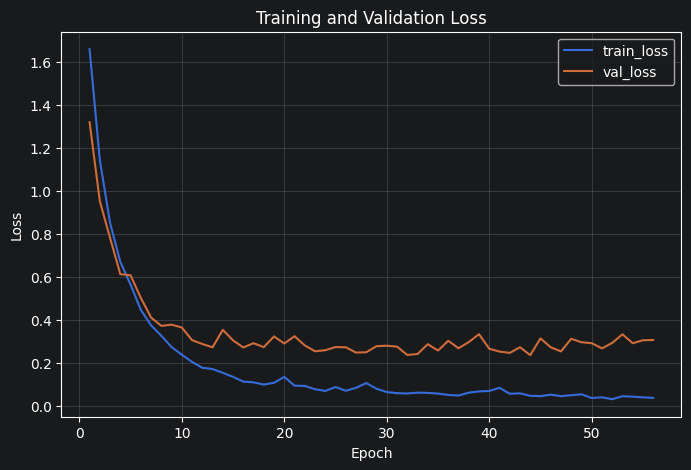

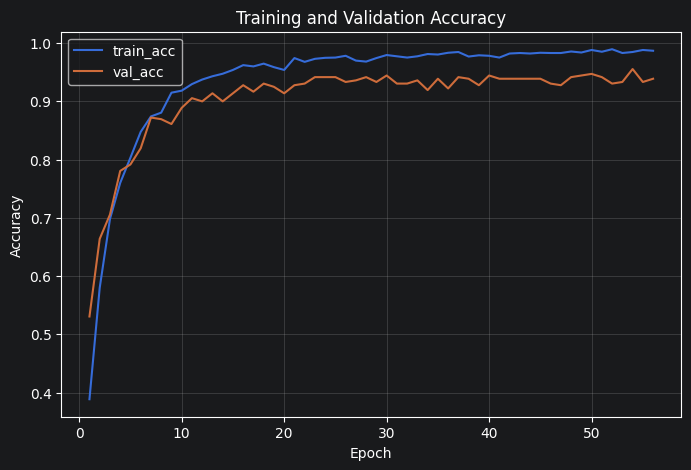

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
loss_fig = FIGURE_DIR / "training_validation_loss.png"
plt.savefig(loss_fig, dpi=160, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_acc"], label="train_acc")
plt.plot(history_df["epoch"], history_df["val_acc"], label="val_acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
acc_fig = FIGURE_DIR / "training_validation_accuracy.png"
plt.savefig(acc_fig, dpi=160, bbox_inches="tight")
plt.show()


## 10. Evaluate on Held-Out Test Actors

In [19]:
checkpoint = torch.load(checkpoint_path, map_location=device)
eval_model = EmotionMLP(input_dim=checkpoint["input_dim"], num_classes=len(LABELS)).to(device)
eval_model.load_state_dict(checkpoint["model_state_dict"])
eval_model.eval()

def predict(model, loader):
    all_preds = []
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            logits = model(xb)
            probs = torch.softmax(logits, dim=1)
            preds = probs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy().tolist())
            all_probs.extend(probs.cpu().numpy().tolist())
            all_labels.extend(yb.numpy().tolist())

    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

y_true, y_pred, y_prob = predict(eval_model, test_loader)

metrics = {
    "test_accuracy": float(accuracy_score(y_true, y_pred)),
    "test_macro_f1": float(f1_score(y_true, y_pred, average="macro")),
    "test_weighted_f1": float(f1_score(y_true, y_pred, average="weighted")),
    "best_epoch": int(checkpoint["best_epoch"]),
    "best_val_loss": float(checkpoint["best_val_loss"]),
}
atomic_write_text(REPORT_DIR / "metrics.json", json.dumps(metrics, indent=2))
metrics

{'test_accuracy': 0.9388888888888889,
 'test_macro_f1': 0.9385783843783334,
 'test_weighted_f1': 0.9389280544480002,
 'best_epoch': 44,
 'best_val_loss': 0.23609288665983413}

In [20]:
report = classification_report(y_true, y_pred, target_names=LABELS, digits=4)
print(report)
atomic_write_text(REPORT_DIR / "classification_report.txt", report)


              precision    recall  f1-score   support

     neutral     1.0000    0.8750    0.9333        24
        calm     0.9362    0.9167    0.9263        48
       happy     0.8980    0.9167    0.9072        48
         sad     0.9565    0.9167    0.9362        48
       angry     0.9778    0.9167    0.9462        48
     fearful     0.9792    0.9792    0.9792        48
     disgust     0.8868    0.9792    0.9307        48
   surprised     0.9216    0.9792    0.9495        48

    accuracy                         0.9389       360
   macro avg     0.9445    0.9349    0.9386       360
weighted avg     0.9408    0.9389    0.9389       360



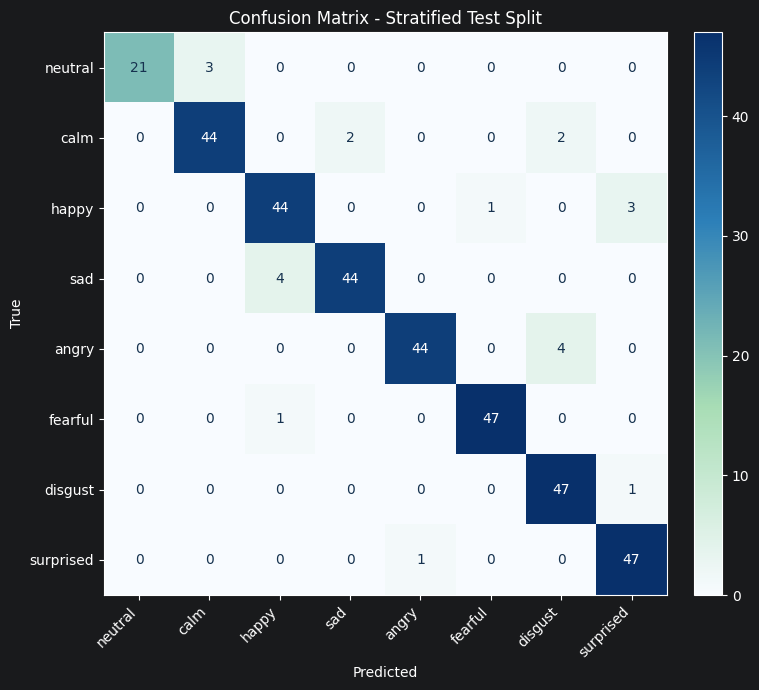

In [21]:
cm = confusion_matrix(y_true, y_pred, labels=list(range(len(LABELS))))
cm_cmap = LinearSegmentedColormap.from_list(
    "ser_confusion",
    ["#f8fbff", "#a8ddb5", "#2c7fb8", "#08306b"],
)

plt.figure(figsize=(8, 7))
plt.imshow(cm, interpolation="nearest", cmap=cm_cmap)
plt.title("Confusion Matrix - Stratified Test Split")
plt.colorbar(fraction=0.046, pad=0.04)
tick_marks = np.arange(len(LABELS))
plt.xticks(tick_marks, LABELS, rotation=45, ha="right")
plt.yticks(tick_marks, LABELS)
plt.xlabel("Predicted")
plt.ylabel("True")

threshold = cm.max() / 2 if cm.size else 0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        text_color = "white" if cm[i, j] > threshold else "#16324f"
        plt.text(j, i, str(cm[i, j]), ha="center", va="center", color=text_color)

plt.tight_layout()
cm_fig = FIGURE_DIR / "confusion_matrix.png"
plt.savefig(cm_fig, dpi=160, bbox_inches="tight")
plt.show()

pd.DataFrame(cm, index=LABELS, columns=LABELS).to_csv(REPORT_DIR / "confusion_matrix.csv")



## 11. OS Analysis Report Section

In [22]:
# Generate report-ready OS analysis text.

cache_hit_rate = manifest["cache_hits"] / max(manifest["num_files"], 1)
parallel_row = benchmark_df[benchmark_df["mode"] == "multiprocessing"].iloc[0].to_dict()
sequential_row = benchmark_df[benchmark_df["mode"] == "sequential"].iloc[0].to_dict()

os_analysis = f"""
# OS Analysis for SER Wav2Vec2 Project

## CPU Scheduling and Process Management
The project uses a Windows-compatible process pool with spawn semantics for CPU-bound audio preprocessing.
Each audio file is treated as an independent task. The process pool dynamically assigns tasks to available workers,
which demonstrates OS scheduling concepts because multiple worker processes compete for CPU time while the OS
scheduler distributes execution across CPU cores.

Benchmark on {int(sequential_row['files'])} sample files:
- Sequential time: {sequential_row['seconds']:.3f} seconds
- Multiprocessing time: {parallel_row['seconds']:.3f} seconds
- Workers: {int(parallel_row['workers'])}
- Speedup vs sequential: {parallel_row['speedup_vs_sequential']:.3f}x

## Synchronization
Cache writing is protected using file locks. Each worker writes to a temporary `.npy` file and then uses atomic replacement.
This prevents race conditions where two processes try to write the same cache file at the same time.

## File Management and System Calls
The project demonstrates file-system operations through directory traversal, file metadata inspection, low-level reads,
low-level writes, fsync-protected manifest writing, and atomic replacement. This shows how user programs interact with
OS file management facilities.

Implemented operations include:
- recursive `.wav` discovery
- `os.stat` for source file metadata
- `os.open`, `os.read`, and `os.close` for low-level read preview
- `os.write`, `os.fsync`, and `os.replace` for durable atomic text writes
- `os.replace` for atomic waveform cache updates
- file deletion when corrupted cache files are detected

## Memory Management
Raw audio is not loaded into memory all at once. Preprocessed audio is cached on disk, and Wav2Vec2 embeddings are
stored using `numpy.memmap`. Memory mapping allows large feature matrices to be accessed without requiring the full
array to be permanently resident in RAM.

## I/O Management and Caching
The audio preprocessing cache stores mono 16 kHz waveforms. When the notebook is re-run, existing valid cache files are reused.
This reduces repeated disk reads, decoding, and resampling work.

Full preprocessing:
- Files processed: {manifest['num_files']}
- Cache hits: {manifest['cache_hits']}
- Cache misses: {manifest['cache_misses']}
- Cache hit rate: {cache_hit_rate:.2%}
- Full preprocessing time: {manifest['full_preprocessing_time_sec']:.3f} seconds

## GPU Resource Management
Wav2Vec2 feature extraction runs in the main process to avoid Windows CUDA multiprocessing instability.
The notebook uses batching and `torch.no_grad()` for inference. On CUDA, mixed precision is used to reduce GPU memory use.

## Performance Trade-offs
1. More preprocessing workers can increase CPU throughput, but too many workers can create context-switch overhead and disk contention.
2. Larger Wav2Vec2 batches improve GPU utilization, but may cause CUDA out-of-memory errors.
3. Caching uses extra disk space, but saves repeated preprocessing time.
4. `fsync` improves durability, but can slow down writes.
5. `numpy.memmap` reduces RAM pressure, but can be slower than pure RAM access for small arrays.
"""

atomic_write_text(REPORT_DIR / "os_analysis.md", os_analysis)
print(os_analysis)



# OS Analysis for SER Wav2Vec2 Project

## CPU Scheduling and Process Management
The project uses a Windows-compatible process pool with spawn semantics for CPU-bound audio preprocessing.
Each audio file is treated as an independent task. The process pool dynamically assigns tasks to available workers,
which demonstrates OS scheduling concepts because multiple worker processes compete for CPU time while the OS
scheduler distributes execution across CPU cores.

Benchmark on 32 sample files:
- Sequential time: 3.658 seconds
- Multiprocessing time: 7.066 seconds
- Workers: 4
- Speedup vs sequential: 0.518x

## Synchronization
Cache writing is protected using file locks. Each worker writes to a temporary `.npy` file and then uses atomic replacement.
This prevents race conditions where two processes try to write the same cache file at the same time.

## File Management and System Calls
The project demonstrates file-system operations through directory traversal, file metadata inspection, lo

## 12. Tests and QA Checks

In [23]:
# Tests

# 1. Filename parser
parsed = parse_ravdess_filename(wav_files[0])
assert "emotion" in parsed and parsed["emotion"] in LABELS

# 2. Label mapping
assert set(metadata["emotion"].unique()).issubset(set(LABELS))
assert metadata["label_id"].between(0, len(LABELS) - 1).all()

# 3. Cache files exist
missing_cache = [p for p in metadata["cache_path"].tolist() if not Path(p).exists()]
assert len(missing_cache) == 0, f"Missing cache files: {missing_cache[:5]}"

# 4. Stratified split coverage
assert len(train_df) + len(val_df) + len(test_df) == len(metadata)
assert set(train_df["label_id"].unique()) == set(range(len(LABELS)))
assert set(val_df["label_id"].unique()) == set(range(len(LABELS)))
assert set(test_df["label_id"].unique()) == set(range(len(LABELS)))

# 5. Feature shapes
assert X_train.shape[0] == len(train_df)
assert X_val.shape[0] == len(val_df)
assert X_test.shape[0] == len(test_df)
assert X_train.shape[1] == hidden_size

# 6. No NaN or infinite features
assert np.isfinite(X_train).all()
assert np.isfinite(X_val).all()
assert np.isfinite(X_test).all()
assert np.isfinite(X_train_balanced).all()

# 7. SMOTE balancing
balanced_counts = pd.Series(y_train_balanced).value_counts()
assert balanced_counts.nunique() == 1
assert X_train_balanced.shape[0] >= X_train.shape[0]

# 8. Prediction shape
assert y_pred.shape[0] == y_test.shape[0]
assert y_prob.shape == (len(y_test), len(LABELS))

qa_results = {
    "filename_parser": "PASS",
    "label_mapping": "PASS",
    "cache_files_exist": "PASS",
    "stratified_split_coverage": "PASS",
    "feature_shapes": "PASS",
    "finite_features": "PASS",
    "smote_balancing": "PASS",
    "prediction_shape": "PASS",
}
atomic_write_text(REPORT_DIR / "qa_results.json", json.dumps(qa_results, indent=2))
qa_results



{'filename_parser': 'PASS',
 'label_mapping': 'PASS',
 'cache_files_exist': 'PASS',
 'stratified_split_coverage': 'PASS',
 'feature_shapes': 'PASS',
 'finite_features': 'PASS',
 'smote_balancing': 'PASS',
 'prediction_shape': 'PASS'}

## 13. Final Output Checklist

In [24]:
output_files = [
    OUTPUT_DIR / "config.json",
    META_DIR / "metadata_with_cache.csv",
    META_DIR / "train_split.csv",
    META_DIR / "val_split.csv",
    META_DIR / "test_split.csv",
    REPORT_DIR / "preprocessing_benchmark.csv",
    REPORT_DIR / "feature_extraction_benchmark.csv",
    REPORT_DIR / "training_history.csv",
    REPORT_DIR / "metrics.json",
    REPORT_DIR / "classification_report.txt",
    REPORT_DIR / "confusion_matrix.csv",
    REPORT_DIR / "os_analysis.md",
    REPORT_DIR / "qa_results.json",
    FIGURE_DIR / "confusion_matrix.png",
    CHECKPOINT_DIR / "best_emotion_mlp.pt",
]

for f in output_files:
    print("OK " if f.exists() else "MISS", f)


OK  C:\Users\LittleFox\Desktop\MUICT#22\Year 2-2 Operating System\ser-os-ravdess-wav2vec2\SER_Wav2Vec2_OS_Project\outputs\config.json
OK  C:\Users\LittleFox\Desktop\MUICT#22\Year 2-2 Operating System\ser-os-ravdess-wav2vec2\SER_Wav2Vec2_OS_Project\data\metadata\metadata_with_cache.csv
OK  C:\Users\LittleFox\Desktop\MUICT#22\Year 2-2 Operating System\ser-os-ravdess-wav2vec2\SER_Wav2Vec2_OS_Project\data\metadata\train_split.csv
OK  C:\Users\LittleFox\Desktop\MUICT#22\Year 2-2 Operating System\ser-os-ravdess-wav2vec2\SER_Wav2Vec2_OS_Project\data\metadata\val_split.csv
OK  C:\Users\LittleFox\Desktop\MUICT#22\Year 2-2 Operating System\ser-os-ravdess-wav2vec2\SER_Wav2Vec2_OS_Project\data\metadata\test_split.csv
OK  C:\Users\LittleFox\Desktop\MUICT#22\Year 2-2 Operating System\ser-os-ravdess-wav2vec2\SER_Wav2Vec2_OS_Project\outputs\reports\preprocessing_benchmark.csv
OK  C:\Users\LittleFox\Desktop\MUICT#22\Year 2-2 Operating System\ser-os-ravdess-wav2vec2\SER_Wav2Vec2_OS_Project\outputs\repor

## 14. Suggested Report Summary

Use the generated files under `outputs/reports/` to write the final report. The most important evidence for the Operating Systems part is:

- `preprocessing_benchmark.csv`
- `feature_extraction_benchmark.csv`
- `os_analysis.md`
- `qa_results.json`
- `metrics.json`
- `classification_report.txt`
- `confusion_matrix.csv`
- `confusion_matrix.png`

The model demonstrates Speech Emotion Recognition, while the OS project contribution is the optimized execution pipeline around the model.
